In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the Dataset
from google.colab import files
uploaded = files.upload()

Saving user_behavior.csv to user_behavior.csv


In [5]:
import pandas as pd
df = pd.read_csv("user_behavior.csv")
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [6]:
# Check Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [7]:
# Check Missing Values
df.isnull().sum()

,0
User ID,0
Device Model,0
Operating System,0
App Usage Time (min/day),0
Screen On Time (hours/day),0
Battery Drain (mAh/day),0
Number of Apps Installed,0
Data Usage (MB/day),0
Age,0
Gender,0


Business Question:


> How much time do user spend in apps daily?



In [8]:
# Average App Usage
df["App Usage Time (min/day)"].mean()

np.float64(271.12857142857143)

-> The average user spend about 271 minutes per day using apps.

Now, I want to compare Android vs IOS users.

In [9]:
# App Usage by Operating System
df.groupby("Operating System")["App Usage Time (min/day)"].mean()

,App Usage Time (min/day)
Operating System,
Android,268.258123
iOS,282.020548


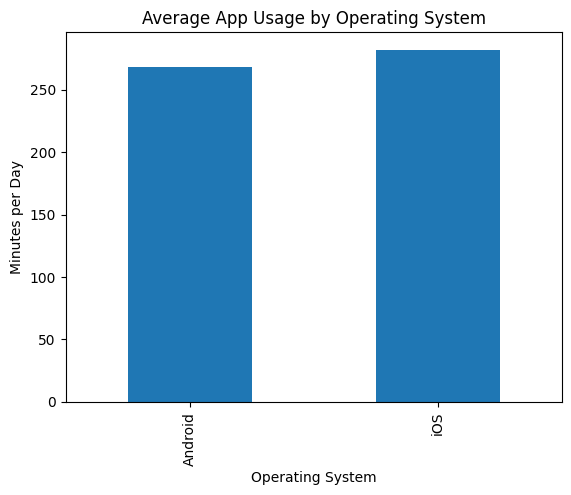

In [10]:
# Visualization IOS vs Android
import matplotlib.pyplot as plt
df.groupby("Operating System")["App Usage Time (min/day)"].mean().plot(kind="bar")

plt.title("Average App Usage by Operating System")
plt.ylabel("Minutes per Day")

plt.show()

-> This chart show IOS system has more users than Android system.

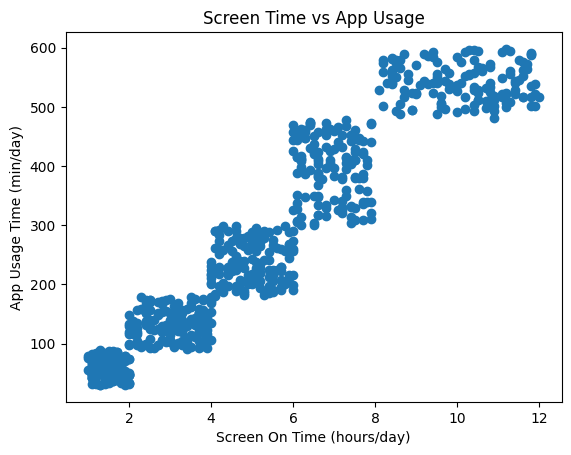

In [11]:
# Visualization Screen Time vs App Usage
plt.scatter(df["Screen On Time (hours/day)"], df["App Usage Time (min/day)"])

plt.xlabel("Screen On Time (hours/day)")
plt.ylabel("App Usage Time (min/day)")
plt.title("Screen Time vs App Usage")

plt.show()

-> Users with higher screen time also have higher app usage.

In [12]:
# Data Usage by Operating System
df.groupby("Operating System")["Data Usage (MB/day)"].mean()

,Data Usage (MB/day)
Operating System,
Android,920.317690
iOS,965.506849


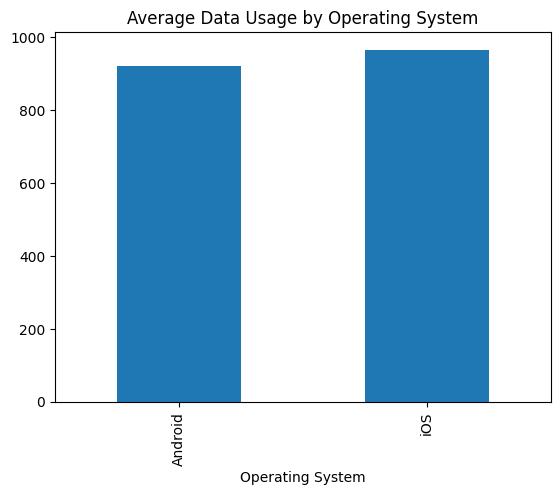

In [13]:
# Visualization Data Usage by Operating System
df.groupby("Operating System")["Data Usage (MB/day)"].mean().plot(kind = "bar")

plt.title("Average Data Usage by Operating System")
plt.show()

In [14]:
# User Behavior Segments
df["User Behavior Class"].value_counts()

,count
User Behavior Class,
2,146
3,143
4,139
5,136
1,136


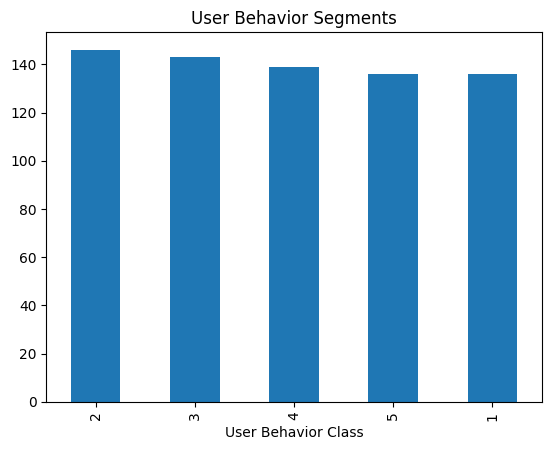

In [15]:
# Visualization
df["User Behavior Class"].value_counts().plot(kind = "bar")
plt.title("User Behavior Segments")
plt.show()

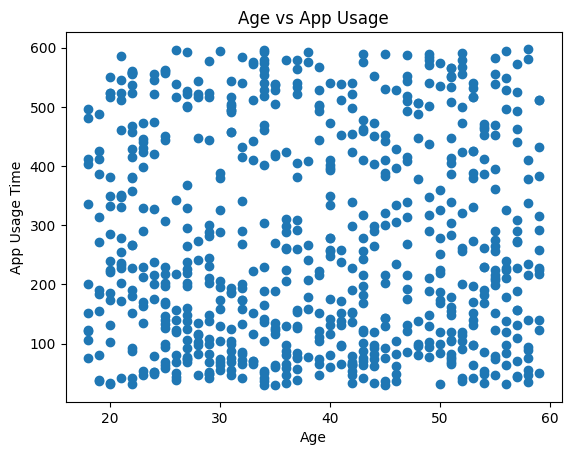

In [16]:
# Age vs App Usage
plt.scatter(df["Age"], df["App Usage Time (min/day)"])

plt.xlabel("Age")
plt.ylabel("App Usage Time")

plt.title("Age vs App Usage")

plt.show()

-> Younger users tend to use apps longer.

**Business Insights**
1. Android users show slightly higher average app usage.
2. Screen time strongly correlates with app engagement.
3. Younger users tend to spend more time on apps.
4. High engagement users belong to behavior class 4.

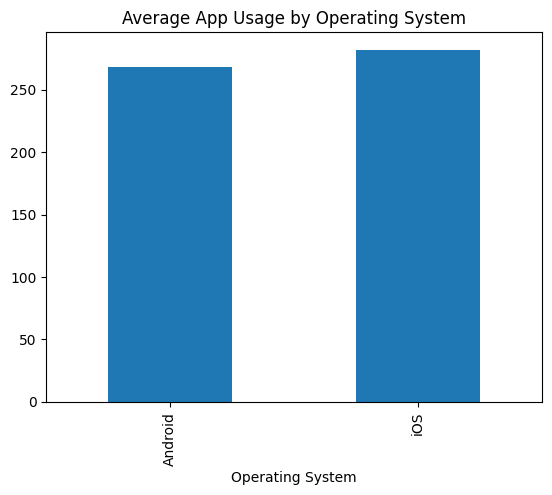

In [17]:
import matplotlib.pyplot as plt
df.groupby("Operating System")["App Usage Time (min/day)"].mean().plot(kind="bar")
plt.title("Average App Usage by Operating System")
plt.savefig("app_usages_os.png")
plt.show()